# Chapter 01. 인과추론 개론과 첫 번째 인과 분석

## 학습 목표
- 상관관계와 인과관계의 차이를 이해한다
- 잠재적 결과 프레임워크를 코드로 시뮬레이션한다
- ATE를 직접 계산해본다
- OpenAI SDK로 첫 번째 인과 분석을 실행한다

## 환경 설정

이 튜토리얼을 실행하기 위해서는 다음 패키지들이 필요하다:
- `openai`: OpenAI API와 SDK
- `pandas`, `numpy`: 데이터 분석
- `scipy`: 통계 분석
- `matplotlib`, `seaborn`: 시각화
- `python-dotenv`: 환경 변수 관리

또한 OpenAI API 키가 필요하다. `.env` 파일에 `OPENAI_API_KEY=sk-...` 형식으로 저장하면 된다.

In [ ]:
# 필요한 패키지 설치
%pip install -q openai python-dotenv pandas numpy scipy matplotlib seaborn

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from openai import OpenAI

# 환경 설정
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
print("환경 설정 완료!")

환경 설정 완료!


In [4]:
import matplotlib.pyplot as plt
import platform
from matplotlib import font_manager, rc

# 1. OS별 폰트 설정
if platform.system() == 'Windows':
    font_name = 'Malgun Gothic'
elif platform.system() == 'Darwin': # Mac
    font_name = 'AppleGothic'
else: # Linux
    font_name = 'NanumGothic'

# 2. matplotlib에 폰트 설정 적용
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False #

## 1. 상관관계 vs 인과관계

상관관계(correlation)와 인과관계(causation)는 다르다. 높은 상관계수를 가진 두 변수가 인과관계를 가지지 않을 수 있다.

**고전적인 예: 아이스크림 판매량과 익사 사고**
- 여름에는 아이스크림 판매량이 증가한다
- 여름에는 익사 사고도 증가한다
- 두 변수 사이에 높은 양의 상관관계가 있다
- 하지만 아이스크림을 팔아서 익사 사고가 증가하는 것은 아니다
- **진짜 원인: 기온이라는 교란변수(Confounder)**

아이스크림 판매량과 익사 사고의 상관계수: 0.683
→ 높은 양의 상관관계이지만, 인과관계는 아니다!


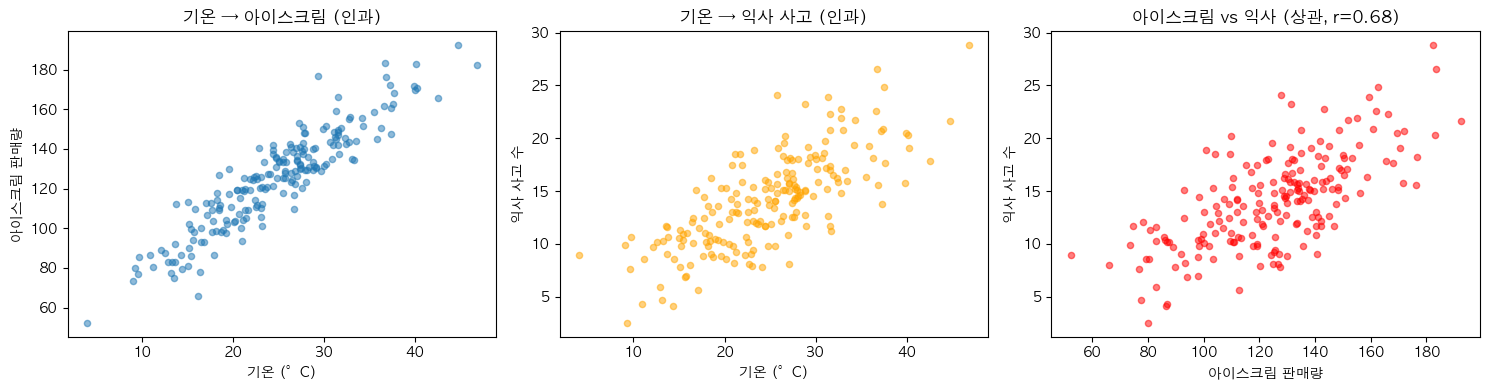

In [5]:
# ============================================================
# 상관관계 ≠ 인과관계 시뮬레이션
# ============================================================
# 아이스크림 판매량과 익사 사고 수는 높은 상관관계를 보이지만,
# 실제 원인은 "기온"이라는 교란변수(Confounder)이다.

np.random.seed(42)
n = 200

# 교란변수: 기온 (진짜 원인)
temperature = np.random.normal(25, 8, n)

# 아이스크림 판매량: 기온에 영향을 받는다
ice_cream = 50 + 3 * temperature + np.random.normal(0, 10, n)

# 익사 사고: 기온에 영향을 받는다 (아이스크림과는 무관)
drowning = 2 + 0.5 * temperature + np.random.normal(0, 3, n)

# 상관계수 계산
correlation = np.corrcoef(ice_cream, drowning)[0, 1]
print(f"아이스크림 판매량과 익사 사고의 상관계수: {correlation:.3f}")
print(f"→ 높은 양의 상관관계이지만, 인과관계는 아니다!")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(temperature, ice_cream, alpha=0.5, s=20)
axes[0].set_xlabel('기온 (°C)')
axes[0].set_ylabel('아이스크림 판매량')
axes[0].set_title('기온 → 아이스크림 (인과)')

axes[1].scatter(temperature, drowning, alpha=0.5, s=20, color='orange')
axes[1].set_xlabel('기온 (°C)')
axes[1].set_ylabel('익사 사고 수')
axes[1].set_title('기온 → 익사 사고 (인과)')

axes[2].scatter(ice_cream, drowning, alpha=0.5, s=20, color='red')
axes[2].set_xlabel('아이스크림 판매량')
axes[2].set_ylabel('익사 사고 수')
axes[2].set_title(f'아이스크림 vs 익사 (상관, r={correlation:.2f})')

plt.tight_layout()
plt.show()

## 2. 잠재적 결과 프레임워크 (Rubin Causal Model)

**인과추론의 근본 문제(Fundamental Problem of Causal Inference)**

각 개인 i에 대해:
- Yi(1): 처치(treatment)를 받았을 때의 잠재적 결과
- Yi(0): 처치를 받지 않았을 때의 잠재적 결과
- 개인 처치효과: τi = Yi(1) - Yi(0)

**핵심 문제: 한 개인에 대해 두 잠재적 결과를 동시에 관찰할 수 없다!**
- 어떤 개인이 처치를 받으면: Yi(1) 만 관찰 가능, Yi(0)은 반사실적(counterfactual)
- 어떤 개인이 처치를 받지 않으면: Yi(0) 만 관찰 가능, Yi(1)은 반사실적

따라서 인과추론은 "관찰되지 않는 반사실적 결과를 추정하는 과정"이다.

In [6]:
# ============================================================
# 잠재적 결과 프레임워크 시뮬레이션
# ============================================================
# "신의 시점"에서 두 잠재적 결과를 모두 생성한다.
# 현실에서는 한 사람에 대해 하나만 관찰 가능하다.

np.random.seed(42)
n = 1000

# 잠재적 결과 생성 (신의 시점 — 현실에서는 관찰 불가)
Y0 = np.random.normal(60, 15, n)    # Y(0): 처치 안 받았을 때의 결과
tau = 5                                # 진짜 처치효과 = 5
Y1 = Y0 + tau + np.random.normal(0, 3, n)  # Y(1): 처치 받았을 때의 결과

# 진짜 ATE (Average Treatment Effect)
true_ate = np.mean(Y1 - Y0)
print(f"진짜 ATE (신의 시점): {true_ate:.2f}")
print(f"설정한 처치효과 τ = {tau}")
print()

# 무작위배정 (RCT): 동전 던지기로 처치 할당
D = np.random.binomial(1, 0.5, n)  # 1: 처치군, 0: 대조군

# 관찰되는 결과 (Switching Equation)
# Yi = Di * Yi(1) + (1 - Di) * Yi(0)
Y_observed = D * Y1 + (1 - D) * Y0

# RCT에서의 ATE 추정
ate_estimate = np.mean(Y_observed[D == 1]) - np.mean(Y_observed[D == 0])
print(f"RCT 추정 ATE: {ate_estimate:.2f}")
print(f"추정 오차: {abs(ate_estimate - true_ate):.2f}")
print()

# 잠재적 결과 테이블 (처음 10명)
df = pd.DataFrame({
    'Y(0)': Y0[:10].round(1),
    'Y(1)': Y1[:10].round(1),
    '개인 처치효과 τ_i': (Y1[:10] - Y0[:10]).round(1),
    '처치 D': D[:10],
    '관찰된 Y': Y_observed[:10].round(1),
    '관찰 불가': ['Y(1)' if d == 0 else 'Y(0)' for d in D[:10]]
})
print("=== 잠재적 결과 테이블 (처음 10명) ===")
print(df.to_string(index=True))
print()
print("→ '관찰 불가' 열이 인과추론의 근본 문제를 보여준다.")

진짜 ATE (신의 시점): 5.21
설정한 처치효과 τ = 5

RCT 추정 ATE: 6.87
추정 오차: 1.66

=== 잠재적 결과 테이블 (처음 10명) ===
   Y(0)  Y(1)  개인 처치효과 τ_i  처치 D  관찰된 Y 관찰 불가
0  67.5  76.6          9.2     0   67.5  Y(1)
1  57.9  65.7          7.8     0   57.9  Y(1)
2  69.7  74.9          5.2     0   69.7  Y(1)
3  82.8  85.9          3.1     0   82.8  Y(1)
4  56.5  63.6          7.1     1   63.6  Y(0)
5  56.5  62.7          6.2     1   62.7  Y(0)
6  83.7  91.4          7.7     0   83.7  Y(1)
7  71.5  78.4          6.9     1   78.4  Y(0)
8  53.0  61.1          8.1     1   61.1  Y(0)
9  68.1  71.5          3.4     0   68.1  Y(1)

→ '관찰 불가' 열이 인과추론의 근본 문제를 보여준다.


## 3. 선택 편향(Selection Bias)

무작위배정이 없으면 선택 편향이 발생한다.

**선택 편향 공식:**
```
E[Y|D=1] - E[Y|D=0] = ATE + Selection Bias
                     = ATE + (E[Y(0)|D=1] - E[Y(0)|D=0])
```

**예: 운동 프로그램의 효과**
- 건강한 사람이 운동에 더 많이 참여한다
- 단순히 "운동군의 체력 - 비운동군의 체력"을 비교하면
- 운동의 진짜 효과 + 건강 수준의 차이가 섞여 있다

In [7]:
# ============================================================
# 선택 편향(Selection Bias) 시뮬레이션
# ============================================================
# 무작위배정이 아닌 경우, 선택 편향이 발생한다.
# 예: 건강한 사람이 운동 프로그램에 더 많이 참여하는 경우

np.random.seed(42)
n = 2000

# 건강 상태 (교란변수)
health = np.random.normal(50, 10, n)

# Y(0): 운동 안 할 때의 체력 점수 (건강 상태에 비례)
Y0 = 30 + 0.5 * health + np.random.normal(0, 5, n)

# Y(1): 운동 할 때의 체력 점수 (진짜 효과 = 3점)
true_effect = 3
Y1 = Y0 + true_effect + np.random.normal(0, 2, n)

# 선택 편향이 있는 처치 할당: 건강한 사람이 운동할 확률 높음
prob_exercise = 1 / (1 + np.exp(-(health - 50) / 5))  # 시그모이드 함수
D_biased = np.random.binomial(1, prob_exercise, n)

# 관찰된 결과
Y_biased = D_biased * Y1 + (1 - D_biased) * Y0

# 나이브 추정 (단순 비교) → 선택 편향 포함
naive_estimate = np.mean(Y_biased[D_biased == 1]) - np.mean(Y_biased[D_biased == 0])

# 진짜 ATE
true_ate = np.mean(Y1 - Y0)

print(f"진짜 ATE: {true_ate:.2f}")
print(f"나이브 추정 (선택 편향 포함): {naive_estimate:.2f}")
print(f"선택 편향 크기: {naive_estimate - true_ate:.2f}")
print()
print("→ 건강한 사람이 운동에 더 많이 참여하므로,")
print("→ 나이브 추정치가 진짜 효과보다 과대추정된다!")

진짜 ATE: 2.90
나이브 추정 (선택 편향 포함): 9.11
선택 편향 크기: 6.20

→ 건강한 사람이 운동에 더 많이 참여하므로,
→ 나이브 추정치가 진짜 효과보다 과대추정된다!


## 4. 첫 번째 인과 분석 — OpenAI SDK 활용

이제 실제 데이터로 인과 분석을 수행해본다.

**데이터셋**: `online_classroom.csv`
**질문**: 온라인 수업(format_ol)이 최종 시험 점수(falsexam)에 미치는 인과적 효과는 무엇인가?
**방법**: Difference in Means (RCT 데이터이므로 무작위배정 성립)

In [8]:
# ============================================================
# 실제 데이터로 첫 번째 인과 분석: online_classroom.csv
# ============================================================
# 질문: 온라인 수업(format_ol)이 시험 점수(falsexam)에 미치는 효과는?

# 데이터 로드
data_path = "./dataset/online_classroom.csv"
df = pd.read_csv(data_path)
df.head()

,gender,asian,black,hawaiian,hispanic,unknown,white,format_ol,format_blended,falsexam
0,0,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,63.29997
1,1,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,79.96000
2,1,0.0,0.0,0.0,0.0,0.0,1.0,0,1.0,83.37000
3,1,0.0,0.0,0.0,0.0,0.0,1.0,0,1.0,90.01994
4,1,0.0,0.0,0.0,0.0,0.0,1.0,1,0.0,83.30000


In [11]:
print(f"행 수: {df.shape[0]}, 열 수: {df.shape[1]}")
print(f"\n컬럼 목록: {list(df.columns)}")

행 수: 323, 열 수: 10

컬럼 목록: ['gender', 'asian', 'black', 'hawaiian', 'hispanic', 'unknown', 'white', 'format_ol', 'format_blended', 'falsexam']


In [12]:
df.describe().round(2)

,gender,asian,black,hawaiian,hispanic,unknown,white,format_ol,format_blended,falsexam
count,323.00,247.00,247.00,247.00,247.00,247.00,247.00,323.00,323.00,323.00
mean,0.58,0.21,0.07,0.01,0.02,0.00,0.68,0.29,0.34,76.63
std,0.49,0.41,0.25,0.11,0.13,0.06,0.47,0.45,0.47,11.67
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,70.02
50%,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,78.33
75%,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,84.99
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,96.68


In [13]:
# ============================================================
# OpenAI Structured Outputs로 인과 변수 자동 식별
# ============================================================
from pydantic import BaseModel, Field
from typing import List, Optional

class CausalVariables(BaseModel):
    """인과 분석에 필요한 변수를 식별하는 모델이다."""
    treatment: str = Field(description="처치 변수명 (Treatment)")
    outcome: str = Field(description="결과 변수명 (Outcome)")
    covariates: List[str] = Field(description="통제할 공변량 리스트")
    is_rct: bool = Field(description="무작위 대조 실험인지 여부")
    reasoning: str = Field(description="변수 선택 근거")

# 데이터셋 정보를 LLM에 전달
columns_info = df.dtypes.to_string()
sample_data = df.head(3).to_string()

response = client.beta.chat.completions.parse(
    model="gpt-4o-mini",
    messages=[
        {
            "role": "system",
            "content": "너는 인과추론 전문가이다. 데이터셋과 질문을 분석하여 인과 분석에 필요한 변수를 식별한다."
        },
        {
            "role": "user",
            "content": f"""다음 데이터셋에서 인과 분석에 필요한 변수를 식별해줘.

    질문: "온라인 수업 형식(format_ol)이 최종 시험 점수(falsexam)에 미치는 인과적 효과는 무엇인가?"
    
    컬럼 정보:
    {columns_info}
    
    샘플 데이터:
    {sample_data}
"""
        }
    ],
    response_format=CausalVariables
)

variables = response.choices[0].message.parsed
print("=== LLM 기반 변수 식별 결과 ===")
print(f"처치 변수: {variables.treatment}")
print(f"결과 변수: {variables.outcome}")
print(f"공변량: {variables.covariates}")
print(f"RCT 여부: {variables.is_rct}")
print(f"근거: {variables.reasoning}")

=== LLM 기반 변수 식별 결과 ===
처치 변수: format_ol
결과 변수: falsexam
공변량: ['gender', 'asian', 'black', 'hawaiian', 'hispanic', 'unknown', 'white', 'format_blended']
RCT 여부: False
근거: The treatment variable is 'format_ol', which represents the online class format, while the outcome variable is 'falsexam', which is the final exam score. Covariates include demographic factors such as gender and ethnic backgrounds that may influence the outcome.


In [14]:
# ============================================================
# ATE 추정: 단순 평균 차이 (Difference in Means)
# ============================================================
from scipy import stats

treatment_col = variables.treatment
outcome_col = variables.outcome

# 처치군과 대조군 분리
treated = df[df[treatment_col] == 1][outcome_col]
control = df[df[treatment_col] == 0][outcome_col]

# ATE 추정
ate = treated.mean() - control.mean()
se = np.sqrt(treated.var()/len(treated) + control.var()/len(control))
t_stat = ate / se
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=len(treated)+len(control)-2))
ci_lower = ate - 1.96 * se
ci_upper = ate + 1.96 * se

print("=== Difference in Means 결과 ===")
print(f"처치군 평균: {treated.mean():.2f} (n={len(treated)})")
print(f"대조군 평균: {control.mean():.2f} (n={len(control)})")
print(f"ATE 추정치: {ate:.2f}")
print(f"표준오차: {se:.2f}")
print(f"t-통계량: {t_stat:.2f}")
print(f"p-value: {p_value:.4f}")
print(f"95% 신뢰구간: [{ci_lower:.2f}, {ci_upper:.2f}]")

=== Difference in Means 결과 ===
처치군 평균: 73.64 (n=94)
대조군 평균: 77.86 (n=229)
ATE 추정치: -4.22
표준오차: 1.67
t-통계량: -2.53
p-value: 0.0119
95% 신뢰구간: [-7.49, -0.95]


In [10]:
# ============================================================
# OpenAI SDK로 인과 분석 결과를 자연어로 해석한다
# ============================================================
response = client.chat.completions.create(
    model="gpt-4o-mini",
    temperature=0,
    messages=[
        {
            "role": "system",
            "content": "너는 인과추론 전문가이다. 통계 분석 결과를 비전공자도 이해할 수 있도록 해석해준다."
        },
        {
            "role": "user",
            "content": f"""다음 인과 분석 결과를 해석해줘.

질문: 온라인 수업이 시험 점수에 미치는 효과
방법: Difference in Means (RCT 데이터)
ATE: {ate:.2f}
표준오차: {se:.2f}
p-value: {p_value:.4f}
95% 신뢰구간: [{ci_lower:.2f}, {ci_upper:.2f}]
처치군 크기: {len(treated)}, 대조군 크기: {len(control)}
"""
        }
    ]
)

print("=== LLM 기반 결과 해석 ===")
print(response.choices[0].message.content)

=== LLM 기반 결과 해석 ===
이 분석 결과는 온라인 수업이 시험 점수에 미치는 영향을 평가한 것입니다. 각 요소를 하나씩 살펴보겠습니다.

1. **ATE (Average Treatment Effect)**: -4.22
   - ATE는 처치군(온라인 수업을 받은 그룹)과 대조군(온라인 수업을 받지 않은 그룹) 간의 평균 점수 차이를 나타냅니다. 여기서 -4.22는 온라인 수업을 받은 학생들이 대조군에 비해 평균적으로 4.22점 낮은 시험 점수를 받았다는 것을 의미합니다.

2. **표준오차 (Standard Error)**: 1.67
   - 표준오차는 ATE의 추정치가 얼마나 변동성이 있는지를 나타냅니다. 값이 작을수록 ATE의 추정이 더 정확하다는 것을 의미합니다.

3. **p-value**: 0.0119
   - p-value는 ATE가 우연히 발생할 확률을 나타냅니다. 일반적으로 p-value가 0.05보다 작으면 통계적으로 유의미하다고 판단합니다. 여기서 p-value가 0.0119이므로, 온라인 수업이 시험 점수에 미치는 영향이 통계적으로 유의미하다고 볼 수 있습니다.

4. **95% 신뢰구간 (Confidence Interval)**: [-7.49, -0.95]
   - 신뢰구간은 ATE의 추정치가 실제로 존재할 가능성이 있는 범위를 나타냅니다. 이 경우, 온라인 수업이 시험 점수에 미치는 효과는 -7.49점에서 -0.95점 사이에 있을 것으로 예상됩니다. 즉, 온라인 수업이 시험 점수를 평균적으로 0.95점에서 7.49점 낮출 수 있다는 것을 의미합니다.

5. **처치군 크기**: 94, 대조군 크기: 229
   - 처치군은 94명, 대조군은 229명으로, 두 그룹의 크기가 다릅니다. 대조군이 더 크기 때문에 결과의 신뢰성이 높아질 수 있습니다.

종합적으로, 이 분석 결과는 온라인 수업이 학생들의 시험 점수를 평균적으로 낮추는 경향이 있으며, 이 결과는 통계적으로 유의미하다는 것을 보여줍니다. 따라서, 온라인 수업의 효과에 대

## 5. 파이프라인 구조

이 책에서 구현하는 **Causal Agent System** 파이프라인은 8단계로 이루어진다.

각 단계에서 OpenAI SDK가 사용된다:
1. **Input Parser**: 자연어 질문 파싱
2. **Dataset Analyzer**: 데이터셋 통계 분석
3. **Query Interpreter**: 변수 식별 (Structured Outputs)
4. **Method Selector**: 방법론 선택 (의사결정 트리)
5. **Method Validator**: 가정 검증
6. **Method Executor**: 인과효과 추정
7. **Explanation Generator**: 결과 해석 (chat.completions)
8. **Output Formatter**: 출력 포맷팅

In [11]:
# ============================================================
# CAIS 8단계 파이프라인 시각화
# ============================================================
pipeline = [
    ("1. Input Parser", "자연어 질문 파싱", "query → parsed_info"),
    ("2. Dataset Analyzer", "데이터셋 통계 분석", "path → analysis"),
    ("3. Query Interpreter", "변수 식별 (LLM)", "query + data → variables"),
    ("4. Method Selector", "방법론 선택 (의사결정 트리)", "variables → method"),
    ("5. Method Validator", "가정 검증", "method + data → validation"),
    ("6. Method Executor", "인과효과 추정", "method + data → results"),
    ("7. Explanation Generator", "결과 해석 (LLM)", "results → explanation"),
    ("8. Output Formatter", "출력 포맷팅", "all → final_output"),
]

print("=== CAIS 자동화 파이프라인 ===")
print("=" * 65)
for i, (name, desc, io) in enumerate(pipeline):
    print(f"  {name}")
    print(f"    설명: {desc}")
    print(f"    흐름: {io}")
    if i < len(pipeline) - 1:
        print(f"    {'↓':>5}")
print("=" * 65)
print("\n이 파이프라인을 OpenAI SDK로 재구현하는 것이 이 책의 핵심이다.")

=== CAIS 자동화 파이프라인 ===
  1. Input Parser
    설명: 자연어 질문 파싱
    흐름: query → parsed_info
        ↓
  2. Dataset Analyzer
    설명: 데이터셋 통계 분석
    흐름: path → analysis
        ↓
  3. Query Interpreter
    설명: 변수 식별 (LLM)
    흐름: query + data → variables
        ↓
  4. Method Selector
    설명: 방법론 선택 (의사결정 트리)
    흐름: variables → method
        ↓
  5. Method Validator
    설명: 가정 검증
    흐름: method + data → validation
        ↓
  6. Method Executor
    설명: 인과효과 추정
    흐름: method + data → results
        ↓
  7. Explanation Generator
    설명: 결과 해석 (LLM)
    흐름: results → explanation
        ↓
  8. Output Formatter
    설명: 출력 포맷팅
    흐름: all → final_output

이 파이프라인을 OpenAI SDK로 재구현하는 것이 이 책의 핵심이다.
